### Masking: two views
Run both cells. Edit the `👈` value in cell 2 and re-run.

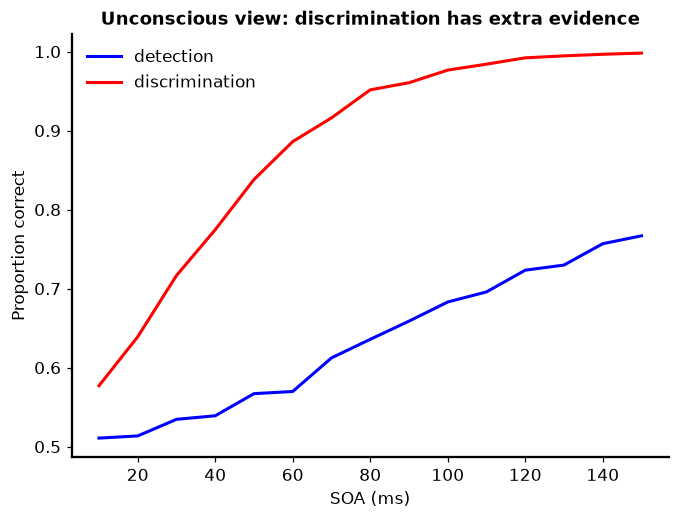

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
rng = np.random.default_rng()

def detection_pc(less, greater, absent1, absent2, crit):
    # detection is correct: |evidence| above criterion on present trials, below on absent
    return (np.mean(np.abs(less) > crit) + np.mean(np.abs(greater) > crit)
            + np.mean(np.abs(absent1) <= crit) + np.mean(np.abs(absent2) <= crit)) / 4

def discrimination_pc(less, greater):
    # correct: "less" evidence below 0, "greater" evidence above 0 (absent trials ignored)
    return (np.mean(less <= 0) + np.mean(greater > 0)) / 2

# The "unconscious perception" view: detection uses conscious evidence; discrimination
# gets EXTRA (unconscious) evidence on top.
nsoa, nsim = 15, 1000
soaEv = np.linspace(0.01, 0.15, nsoa)
noise_sd = 0.0354
detection_criterion = 0.0354

det, disc = [], []
for soa in soaEv:
    less    = rng.standard_normal(nsim)*noise_sd - soa/2
    greater = rng.standard_normal(nsim)*noise_sd + soa/2
    a1 = rng.standard_normal(nsim)*noise_sd
    a2 = rng.standard_normal(nsim)*noise_sd
    det.append(detection_pc(less, greater, a1, a2, detection_criterion))
    # discrimination adds more (unconscious) evidence
    less2    = less    + rng.standard_normal(nsim)*noise_sd - soa/2
    greater2 = greater + rng.standard_normal(nsim)*noise_sd + soa/2
    disc.append(discrimination_pc(less2, greater2))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(soaEv*1000, det,  "b", lw=2, label="detection")
ax.plot(soaEv*1000, disc, "r", lw=2, label="discrimination")
ax.set(xlabel="SOA (ms)", ylabel="Proportion correct",
       title="Unconscious view: discrimination has extra evidence")
ax.legend(loc="upper left")
plt.show()


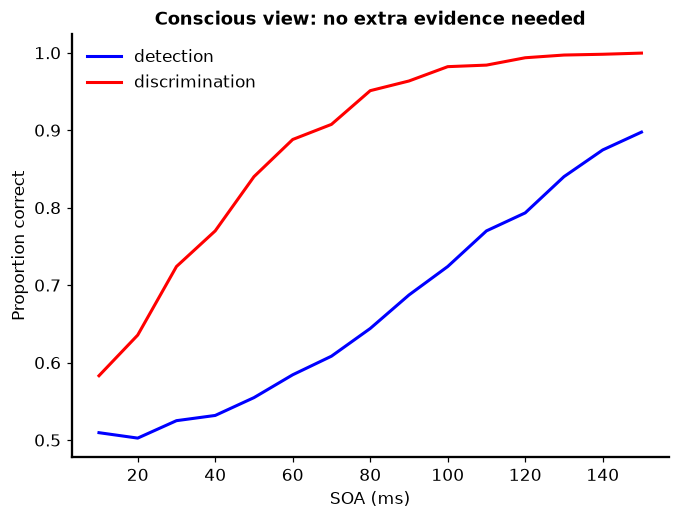

In [2]:
# The "conscious perception" view: ALL evidence is conscious. Discrimination still
# beats detection -- simply because the digits are more different from each other
# than from nothing.
nsoa, nsim = 15, 1000
soaEv = np.linspace(0.01, 0.15, nsoa)
noise_sd = 0.05
detection_criterion = 0.1     # 👈 try changing this

det, disc = [], []
for soa in soaEv:
    less    = rng.standard_normal(nsim)*noise_sd - soa
    greater = rng.standard_normal(nsim)*noise_sd + soa
    a1 = rng.standard_normal(nsim)*noise_sd
    a2 = rng.standard_normal(nsim)*noise_sd
    det.append(detection_pc(less, greater, a1, a2, detection_criterion))
    disc.append(discrimination_pc(less, greater))   # same evidence, no extra

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(soaEv*1000, det,  "b", lw=2, label="detection")
ax.plot(soaEv*1000, disc, "r", lw=2, label="discrimination")
ax.set(xlabel="SOA (ms)", ylabel="Proportion correct",
       title="Conscious view: no extra evidence needed")
ax.legend(loc="upper left")
plt.show()
